# Buổi 6 — Phân rã chuỗi thời gian

**Một câu:** tách chuỗi thành **xu hướng + mùa vụ + phần dư**, rồi kiểm phần dư: còn mẫu hình theo lịch nghĩa là mùa vụ chưa
tách hết — nó đang trốn ở đâu đó.

Tình huống: nhu cầu điện theo giờ của PJM (miền Đông nước Mỹ) năm 2024 lên xuống vì mùa trong năm, nhịp ngày, nhịp tuần, thời
tiết và cả một giờ số liệu hỏng. Sáu phần dưới tách từng thứ.

| Phần | Câu hỏi |
|---|---|
| 1 | Phân rã cổ điển tính thế nào? |
| 2 | Mùa vụ cộng hay nhân, có đổi theo thời gian không? |
| 3 | Phân rã cổ điển chu kỳ 24 để mùa vụ trốn ở đâu? |
| 4 | STL, MSTL làm gì khác? |
| 5 | Mùa vụ "mạnh" cỡ nào — đo bằng một con số? |
| 6 | Một giờ hỏng làm méo phân rã ra sao, robust sửa được gì? |

## 0. Dữ liệu

**Bộ dữ liệu EIA-930 Hourly Electric Grid Monitor — BALANCE.** Cơ quan Thông tin Năng lượng Mỹ (EIA) thu từ mọi **vùng điều độ điện** (balancing authority — đơn vị giữ cân bằng cung
cầu điện trong một vùng, ví dụ PJM ở miền Đông, ERCOT ở Texas) **nhu cầu điện mỗi giờ**, dự báo ngày hôm trước của chính họ,
và sản lượng theo nguồn. Mỗi tệp là sáu tháng, mỗi dòng là **một giờ của một vùng**. Mốc giờ là **cuối giờ**: dòng 01:00 là
lượng điện của giờ 00:00–01:00.

Nguồn: Source: U.S. Energy Information Administration, Form EIA-930 Hourly Electric Grid Monitor (truy cập 2026-09-17); và 1 tệp cùng họ. Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `Balancing Authority` | mã vùng điều độ, ví dụ `PJM`, `ERCO` (ERCOT) |
| `UTC Time at End of Hour` | mốc giờ UTC, là **cuối** giờ đo |
| `Demand (MW)` | nhu cầu điện trung bình trong giờ (MW) — thứ cần dự báo |
| `Demand Forecast (MW)` | dự báo ngày hôm trước của chính vùng điều độ |

Ô dưới tải dữ liệu (90 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [1]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "eia930-balance-2024-h1": ("26768c495c3ba987e29d79df2e40d4e741f9dbcff086f53c12ff774465756a10", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/eia930-balance-2024-h1/EIA930_BALANCE_2024_Jan_Jun.csv",
        "https://www.eia.gov/electricity/gridmonitor/sixMonthFiles/EIA930_BALANCE_2024_Jan_Jun.csv",
    ]),
    "eia930-balance-2024-h2": ("a602a8e577cfdd2fa3083413eaa4dd8ba7f0d2b26a2986f8f6d22917465ea49f", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/eia930-balance-2024-h2/EIA930_BALANCE_2024_Jul_Dec.csv",
        "https://www.eia.gov/electricity/gridmonitor/sixMonthFiles/EIA930_BALANCE_2024_Jul_Dec.csv",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

eia930-balance-2024-h1       /home/tony/.cache/khoa-forecasting/sha256/26/26768c495c3ba987e29d79df2e40d4e741f9dbcff086f53c12ff774465756a10
eia930-balance-2024-h2       /home/tony/.cache/khoa-forecasting/sha256/a6/a602a8e577cfdd2fa3083413eaa4dd8ba7f0d2b26a2986f8f6d22917465ea49f


> **PJM, ERCO, ISNE** · *balancing authority codes*
>
> - **Là gì:** mã vùng điều độ điện trong EIA-930: PJM (13 bang miền Đông nước Mỹ), ERCO (Texas), ISNE (New England).
> - **Ví dụ:** dòng `PJM`, `07/16/2024 10:00:00 PM` cho nhu cầu cả vùng PJM trong giờ kết thúc lúc 22:00 UTC.
> - **Để làm gì:** mỗi vùng là một chuỗi nhu cầu riêng; buổi này phân rã PJM, bài tập so với ERCO và ISNE.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import MSTL, STL, seasonal_decompose

NY = "America/New_York"
THU = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
cot = ["Balancing Authority", "UTC Time at End of Hour", "Demand (MW)"]
eia = pd.concat([pd.read_csv(lay(t), usecols=cot, thousands=",") for t in ("eia930-balance-2024-h1", "eia930-balance-2024-h2")])
eia = eia[eia["Balancing Authority"].isin(["PJM", "ERCO", "ISNE"])]
eia["ds"] = pd.to_datetime(eia["UTC Time at End of Hour"], format="%m/%d/%Y %I:%M:%S %p")    # UTC, mốc CUỐI giờ


def nhu_cau(vung):
    d = eia[eia["Balancing Authority"] == vung]
    return pd.Series(d["Demand (MW)"].to_numpy(float), index=d["ds"]).sort_index().asfreq("h")   # giờ trống → NaN


def dia_phuong(s):
    return pd.Series(s.to_numpy(), index=s.index.tz_localize("UTC").tz_convert(NY))


y_goc = nhu_cau("PJM")
thieu = y_goc[y_goc.isna()]
print(f"PJM: {len(y_goc):,} giờ UTC, {len(thieu)} giờ trống: {thieu.index[0]} … {thieu.index[-1]}")
print("các ngày có giờ trống:", sorted({f"{t:%d/%m}" for t in thieu.index}))
y = y_goc.interpolate(method="time")         # STL/MSTL trả TOÀN NaN nếu còn một NaN → lấp trước khi phân rã

PJM: 8,784 giờ UTC, 47 giờ trống: 2024-03-10 07:00:00 … 2024-11-04 05:00:00
các ngày có giờ trống: ['03/11', '04/11', '10/03', '11/03']


Viết tắt: **T2 … T7** là thứ Hai … thứ Bảy, **CN** là Chủ nhật. 47 giờ trống dồn quanh hai ngày đổi giờ (10/3 và 3/11), nên
nội suy theo thời gian là đủ; đơn vị: **MW** là công suất trong một giờ, **GW** = 1.000 MW.

## 1. Phân rã cổ điển: trung bình đúng một vòng rồi trung bình theo vị trí

**Vấn đề.** Nhu cầu điện lên xuống vì nhiều lý do chồng nhau. Muốn hiểu từng lý do, phải tách chúng ra.

> **phân rã** · *decomposition*
>
> - **Là gì:** tách chuỗi thành các phần cộng lại ra chuỗi: xu hướng + mùa vụ + phần dư.
> - **Ví dụ:** 30 = 24,5 (xu hướng) + 4 (mùa vụ) + 1,5 (phần dư).
> - **Để làm gì:** hiểu từng nguồn biến động riêng — và thấy phần nào mô hình phải tự đoán.
>
> 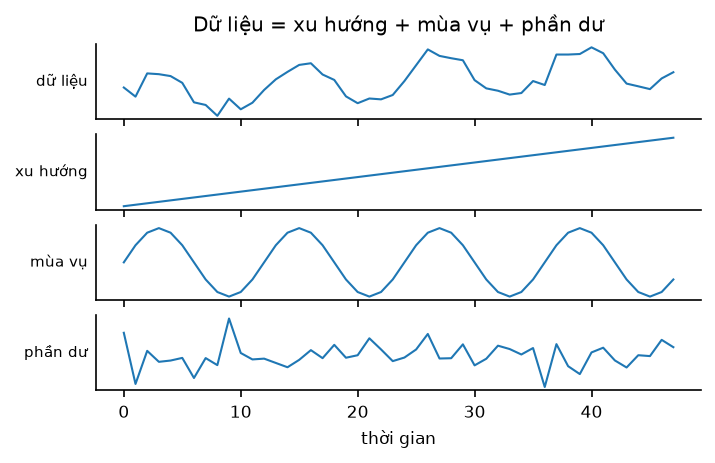

> **phần dư** · *remainder*
>
> - **Là gì:** phần còn lại sau khi trừ xu hướng và mùa vụ; lý tưởng là không còn mẫu hình.
> - **Ví dụ:** ngày mưa bão, giờ số liệu hỏng — những thứ lịch không báo trước.
> - **Để làm gì:** kiểm chất lượng phân rã: phần dư còn nhịp theo lịch là mùa vụ chưa tách hết.

> **2×m-MA** · *centred moving average of order m*
>
> - **Là gì:** trung bình trượt $m$ điểm rồi trung bình trượt 2 điểm, để có tâm khi $m$ chẵn — tức $m + 1$ điểm, hai đầu nửa trọng số.
> - **Ví dụ:** $m$ = 4: trọng số 1/8, 1/4, 1/4, 1/4, 1/8 — quý 1 ở hai đầu, mỗi đầu một nửa.
> - **Để làm gì:** ước lượng xu hướng bằng trung bình đúng một vòng mùa vụ, để mùa vụ tự triệt tiêu.
>
> 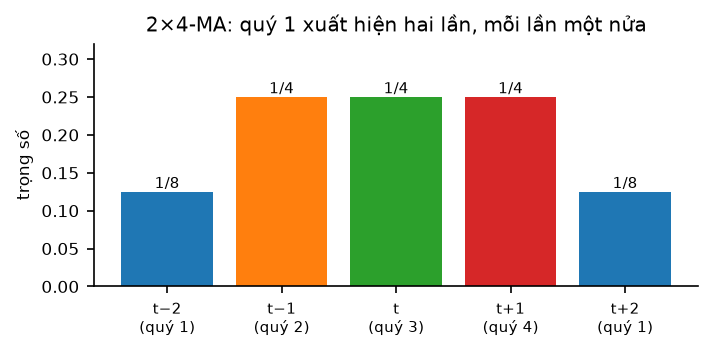

> **khử xu hướng** · *detrend*
>
> - **Là gì:** lấy chuỗi trừ xu hướng: $y - \hat T$.
> - **Ví dụ:** 30 − 24,5 = 5,5 — còn lại mùa vụ + phần dư.
> - **Để làm gì:** bước giữa để tìm mùa vụ.

> **phân rã cổ điển** · *classical decomposition*
>
> - **Là gì:** xu hướng bằng 2×m-MA; mùa vụ bằng trung bình của "dữ liệu trừ xu hướng" theo vị trí trong vòng, giống nhau mọi vòng; phần dư là cái còn lại.
> - **Ví dụ:** 12 quý, $m$ = 4: mùa vụ quý 1 = trung bình hai giá trị 5,5 và 2,5 = 4.
> - **Để làm gì:** cách đơn giản nhất, làm tay được — và là thước so để thấy các cách sau tốt hơn ở đâu.

**Lý do.** Trung bình đúng **một vòng** mùa vụ thì mùa vụ lên rồi xuống, cộng lại bằng 0 — còn xu hướng. Trừ xu hướng, lấy trung
bình theo từng vị trí trong vòng (mọi quý 1, mọi quý 2…) thì phần dư lúc dương lúc âm triệt tiêu — còn mùa vụ. Với $m$ chẵn, xu
hướng là trung bình $m + 1$ điểm, hai đầu nửa trọng số:

$$\hat T_t = \frac{1}{2m}\, y_{t-m/2} + \frac{1}{m} \sum_{j=-(m/2-1)}^{m/2-1} y_{t+j} + \frac{1}{2m}\, y_{t+m/2}$$

**Kết quả.** Ví dụ 12 quý tính tay, rồi so với `statsmodels`:

In [3]:
def co_dien(x, m):
    x = np.asarray(x, dtype=float)
    w = np.r_[0.5, np.ones(m - 1), 0.5] / m                  # m + 1 trọng số, tổng = 1
    T = np.full(x.size, np.nan)
    T[m // 2:-m // 2] = np.convolve(x, w, mode="valid")      # mất m/2 điểm mỗi đầu
    pha = np.arange(x.size) % m                              # vị trí trong vòng
    S_mua = np.array([np.nanmean((x - T)[pha == k]) for k in range(m)])
    S = (S_mua - S_mua.mean())[pha]                          # tổng mùa vụ một vòng = 0
    return T, S, x - T - S


x = np.array([22, 18, 15, 29, 30, 22, 19, 33, 30, 26, 23, 37])
T, S, R = co_dien(x, 4)
print(pd.DataFrame({"y": x, "T": T, "y − T": x - T, "S": S, "R": R}, index=range(1, 13)).T.round(2).to_string())
sm = seasonal_decompose(x, period=4)
print("lệch tối đa so với seasonal_decompose (12 quý):", np.nanmax(np.abs(sm.trend - T)), np.nanmax(np.abs(sm.seasonal - S)))
cd_T, cd_S, _ = co_dien(y.to_numpy(), 24)
sm24 = seasonal_decompose(y, period=24)
print("lệch tối đa trên PJM, chu kỳ 24:", np.nanmax(np.abs(sm24.trend.to_numpy() - cd_T)), np.nanmax(np.abs(sm24.seasonal.to_numpy() - cd_S)))

         1     2     3     4     5     6     7     8     9     10    11    12
y      22.0  18.0  15.0  29.0  30.0  22.0  19.0  33.0  30.0  26.0  23.0  37.0
T       NaN   NaN  22.0  23.5  24.5  25.5  26.0  26.5  27.5  28.5   NaN   NaN
y − T   NaN   NaN  -7.0   5.5   5.5  -3.5  -7.0   6.5   2.5  -2.5   NaN   NaN
S       4.0  -3.0  -7.0   6.0   4.0  -3.0  -7.0   6.0   4.0  -3.0  -7.0   6.0
R       NaN   NaN   0.0  -0.5   1.5  -0.5   0.0   0.5  -1.5   0.5   NaN   NaN
lệch tối đa so với seasonal_decompose (12 quý): 0.0 0.0
lệch tối đa trên PJM, chu kỳ 24: 0.0 0.0


Tại quý 3: 22/8 + (18 + 15 + 29)/4 + 30/8 = **22**. Mùa vụ bốn quý là 4, −3, −7, 6 (tổng 0), phần dư chỉ còn ±0,5 và ±1,5. Hai
quý đầu và hai quý cuối không có xu hướng vì thiếu hàng xóm; trên dữ liệu giờ ($m$ = 24) là 12 giờ mỗi đầu.

**Bài học.** Xu hướng = trung bình trượt đúng một vòng mùa vụ; mùa vụ = trung bình của "dữ liệu trừ xu hướng" theo vị trí trong
vòng; phần dư = phần còn lại. Mười dòng NumPy khớp thư viện tới từng số.

## 2. Biên độ ngày của PJM đổi theo mùa vì điều hoà, không vì mức

**Vấn đề.** Phân rã cổ điển giả định mùa vụ **cộng** thêm và vòng nào cũng **giống hệt** nhau. Với điện, điều thứ hai sai.

> **phân rã cộng / nhân** · *additive / multiplicative decomposition*
>
> - **Là gì:** cộng: mùa vụ là một số cố định cộng thêm. Nhân: mùa vụ là một tỷ lệ nhân thêm.
> - **Ví dụ:** cộng: cao điểm +10 ở mức 100 lẫn mức 200. Nhân: ×1,1, tức +10 ở mức 100, +20 ở mức 200.
> - **Để làm gì:** chọn đúng dạng để mùa vụ không "lớn dần" giả tạo; nhân ⇔ lấy log rồi phân rã cộng.
>
> 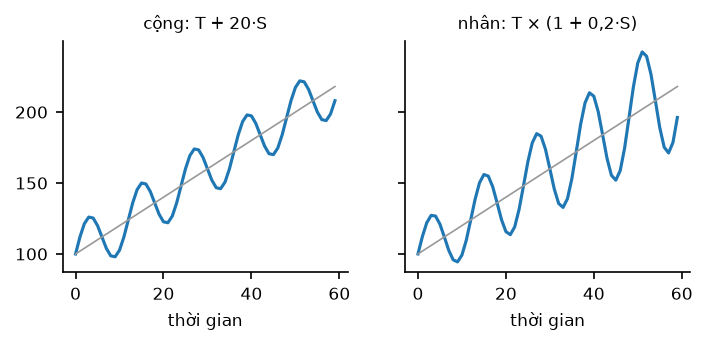

**Lý do.** Nếu dao động tỷ lệ với mức thì dùng phân rã nhân, hoặc log rồi phân rã cộng, vì
$\log(T \times S \times R) = \log T + \log S + \log R$. Nhưng nếu dao động đổi vì lý do khác mức (điều hoà chạy buổi chiều hè), thì cần
mùa vụ **đổi theo thời gian**.

**Kết quả.**

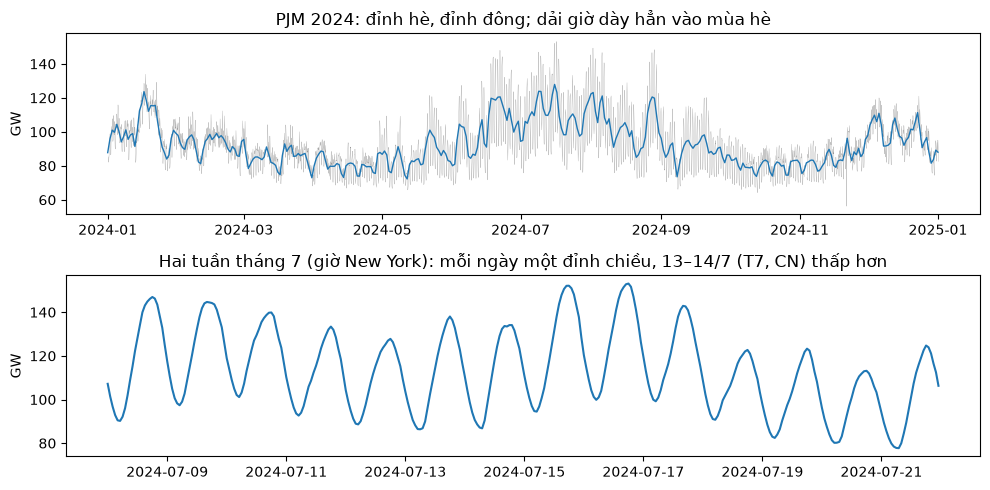

biên độ trong ngày trung bình (GW): {1: 17.0, 4: 17.2, 7: 44.0}
21/11/2024 16h–18h UTC (MW): [94812, 56260, 95482]


In [4]:
fig, (a, b) = plt.subplots(2, 1, figsize=(10, 5))
a.plot(y_goc.index, y_goc.to_numpy() / 1000, color="0.6", lw=0.2)
a.plot(y_goc.resample("D").mean() / 1000, lw=1)
a.set(ylabel="GW", title="PJM 2024: đỉnh hè, đỉnh đông; dải giờ dày hẳn vào mùa hè")
tuan = dia_phuong(y_goc["2024-07-08 04:00":"2024-07-22 03:00"])
b.plot(tuan.index.tz_localize(None), tuan.to_numpy() / 1000)
b.set(ylabel="GW", title="Hai tuần tháng 7 (giờ New York): mỗi ngày một đỉnh chiều, 13–14/7 (T7, CN) thấp hơn")
fig.tight_layout()
plt.show()

ngay = dia_phuong(y).resample("D")
bd = (ngay.max() - ngay.min()) / 1000                        # biên độ trong ngày (GW)
print("biên độ trong ngày trung bình (GW):", bd.groupby(bd.index.month).mean().round(1).loc[[1, 4, 7]].to_dict())
t0 = pd.Timestamp("2024-11-21 17:00")
print("21/11/2024 16h–18h UTC (MW):", y_goc[t0 - pd.Timedelta("1h"):t0 + pd.Timedelta("1h")].astype(int).tolist())

Biên độ trong ngày tháng 7 trung bình 44 GW, tháng 1 chỉ 17 GW, trong khi mức tháng 1 cũng cao: đó là mùa vụ **đổi theo thời
gian**, không phải lý do dùng phân rã nhân. Và một giờ hỏng: 17:00 UTC ngày 21/11 báo 56.260 MW giữa hai giờ khoảng 95.000 MW — phần 6 dùng nó.

**Bài học.** Cộng hay nhân tuỳ biên độ mùa vụ có tỷ lệ với mức không — xu hướng không quyết định điều đó. Điện PJM cần phân rã
cộng với mùa vụ được đổi dần.

## 3. Chu kỳ 24: nhịp tuần trốn vào xu hướng, mùa vụ hè trốn vào phần dư

**Vấn đề.** PJM còn mùa vụ tuần (168 giờ), và mùa vụ ngày đổi theo mùa. Phân rã cổ điển chu kỳ 24 đẩy hai thứ đó đi đâu?

> **tỷ lệ mẫu hình** · *remaining pattern ratio*
>
> - **Là gì:** phương sai của trung bình phần dư theo nhóm lịch (ví dụ tháng × giờ), chia phương sai chuỗi; gần 0 là phần dư sạch.
> - **Ví dụ:** phần dư sáng −3, −5, chiều +3, +5: trung bình nhóm −4 và +4, phương sai 32; chuỗi phương sai 320 → tỷ lệ 0,1.
> - **Để làm gì:** đo "phần dư còn mẫu hình" bằng một con số, để so hai cách phân rã.

**Lý do.** Xu hướng 2×24-MA là trung bình **một ngày**: Chủ nhật thấp thì xu hướng quanh Chủ nhật thấp — nhịp tuần chạy vào xu
hướng. Mùa vụ cổ điển là **một** khuôn 24 giờ cho cả năm — phần riêng của chiều hè ở lại trong phần dư. Đo phần dư bằng tỷ lệ mẫu
hình:

$$\text{tỷ lệ mẫu hình} = \frac{\operatorname{Var}_g\big(\bar R_g\big)}{\operatorname{Var}(y)}$$

**Kết quả.**

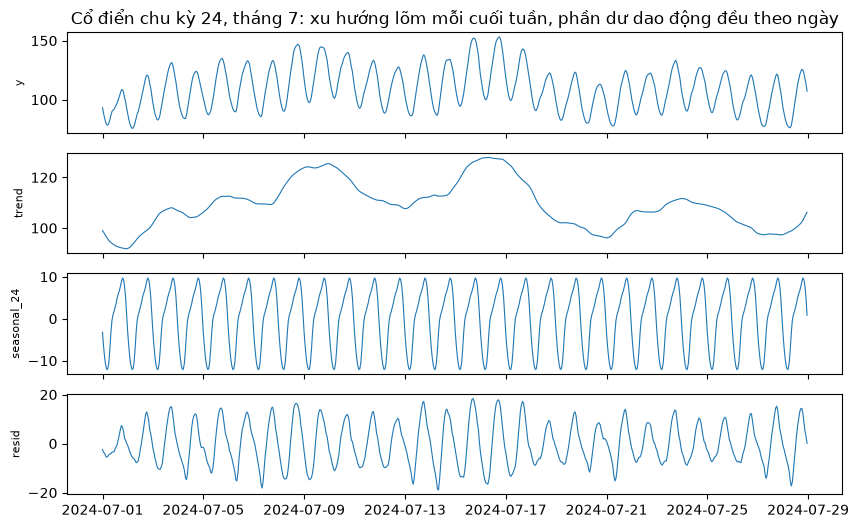

xu hướng TB theo thứ (MW): {'T2': 93327, 'T3': 94611, 'T4': 95036, 'T5': 94917, 'T6': 93654, 'T7': 89523, 'CN': 88459}
cổ điển 24      tỷ lệ mẫu hình tháng×giờ 0.1016 | thứ×giờ 0.00671 | phần dư tháng 7 lúc 17h +13,037 MW
MSTL (24, 168)  tỷ lệ mẫu hình tháng×giờ 0.0006 | thứ×giờ 0.00001 | phần dư tháng 7 lúc 17h -668 MW


In [5]:
cd = pd.DataFrame({"y": y, "trend": sm24.trend, "seasonal_24": sm24.seasonal, "resid": sm24.resid})
ms_kq = MSTL(y, periods=(24, 168)).fit()                      # MSTL: phần 4 giải thích
ms = pd.DataFrame({"y": y, "trend": ms_kq.trend, "resid": ms_kq.resid}).join(ms_kq.seasonal)

thang7 = slice("2024-07-01 04:00", "2024-07-29 03:00")
fig, truc = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
for ax, c in zip(truc, ["y", "trend", "seasonal_24", "resid"], strict=True):
    s = dia_phuong(cd.loc[thang7, c])
    ax.plot(s.index.tz_localize(None), s.to_numpy() / 1000, lw=0.8)
    ax.set_ylabel(c, fontsize=8)
truc[0].set_title("Cổ điển chu kỳ 24, tháng 7: xu hướng lõm mỗi cuối tuần, phần dư dao động đều theo ngày")
plt.show()

xh = dia_phuong(cd["trend"]).dropna()
print("xu hướng TB theo thứ (MW):", dict(zip(THU, xh.groupby(xh.index.dayofweek).mean().round(0).astype(int), strict=True)))


def ho_so_phan_du(bang, theo):
    r = dia_phuong(bang["resid"].dropna())
    return r.groupby([getattr(r.index, k) for k in theo]).mean()


for ten, bang in [("cổ điển 24", cd), ("MSTL (24, 168)", ms)]:
    tl = {k: ho_so_phan_du(bang, k).var() / bang["y"].var() for k in [("month", "hour"), ("dayofweek", "hour")]}
    print(f"{ten:<15} tỷ lệ mẫu hình tháng×giờ {tl[('month', 'hour')]:.4f} | thứ×giờ {tl[('dayofweek', 'hour')]:.5f} | "
          f"phần dư tháng 7 lúc 17h {ho_so_phan_du(bang, ('month', 'hour')).loc[(7, 17)]:+,.0f} MW")

Thứ Bảy, Chủ nhật có xu hướng thấp hơn giữa tuần khoảng 5.500–6.600 MW: nhịp tuần nằm trong xu hướng. Cổ điển để lại khoảng một
phần mười phương sai chuỗi thành mẫu hình tháng × giờ (0,102); MSTL gần như không còn (0,0006). Chiều hè, khuôn chung của cổ
điển thấp hơn dữ liệu khoảng 13 GW. Nhìn bằng heatmap:

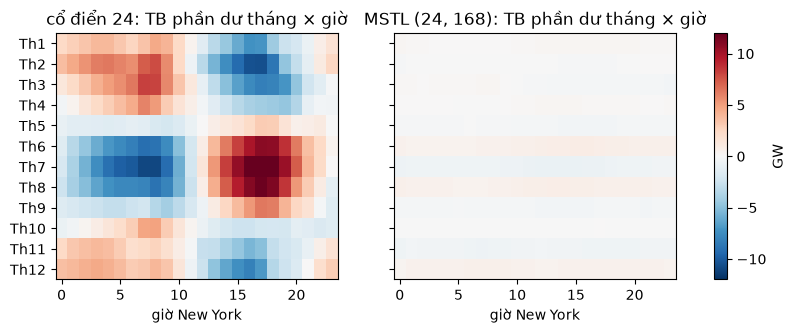

In [6]:
fig, truc = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (ten, bang) in zip(truc, [("cổ điển 24", cd), ("MSTL (24, 168)", ms)], strict=True):
    anh = ax.imshow(ho_so_phan_du(bang, ("month", "hour")).unstack().to_numpy() / 1000, aspect="auto", cmap="RdBu_r", vmin=-12, vmax=12)
    ax.set(xlabel="giờ New York", title=f"{ten}: TB phần dư tháng × giờ")
truc[0].set_yticks(range(12), [f"Th{m}" for m in range(1, 13)])
plt.colorbar(anh, ax=truc, label="GW")
plt.show()

**Bài học.** Kiểm **cả hai** chỗ mùa vụ có thể trốn: trung bình xu hướng theo thứ, và tỷ lệ mẫu hình của phần dư theo tháng × giờ,
thứ × giờ. Chỉ nhìn phần dư theo thứ sẽ kết luận sai "không có mùa vụ tuần".

## 4. STL làm trơn mùa vụ cục bộ; MSTL tách từng chu kỳ

**Vấn đề.** Cần phân rã mà mùa vụ ngày tháng 7 được khác tháng 1, và tách riêng mùa vụ tuần.

> **STL, LOESS** · *Seasonal-Trend decomposition using LOESS*
>
> - **Là gì:** LOESS là làm trơn cục bộ: ở mỗi điểm, khớp một đường qua các điểm lân cận, điểm gần nặng hơn. STL dùng LOESS cho cả mùa vụ và xu hướng, nên mùa vụ được đổi dần qua các vòng.
> - **Ví dụ:** "dữ liệu trừ xu hướng" của quý 1 qua 5 năm: 2, 4, 6, 8, 10. Cổ điển cho mùa vụ 6 mọi năm, phần dư −4 … 4; trung bình cục bộ 3 năm cho 3, 4, 6, 8, 9, phần dư −1 … 1.
> - **Để làm gì:** để mùa vụ tháng 7 được khác tháng 1.
>
> 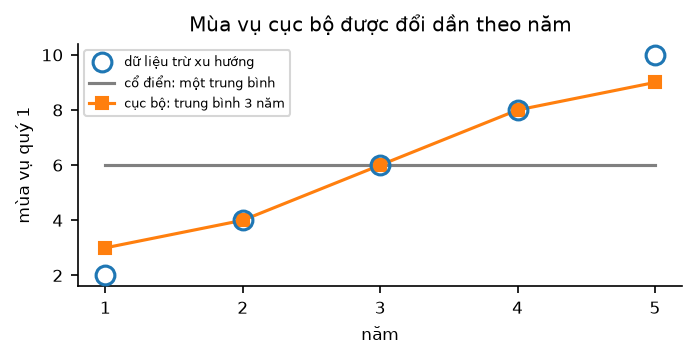

> **MSTL** · *Multiple Seasonal-Trend decomposition using LOESS*
>
> - **Là gì:** STL cho nhiều mùa vụ: tách lần lượt từng chu kỳ, ngắn trước dài sau, lặp lại vòng đó.
> - **Ví dụ:** PJM: tách mùa vụ 24 giờ, rồi 168 giờ khỏi phần còn lại.
> - **Để làm gì:** tách riêng nhịp ngày và nhịp tuần, thay vì để nhịp tuần lẫn vào xu hướng.

**Lý do.** STL có hai cửa sổ (số lẻ): `seasonal` — số vòng lân cận để làm trơn mùa vụ (nhỏ thì đổi nhanh, tối thiểu 7); `trend` —
số điểm lân cận cho xu hướng (mặc định với $m$ = 24 là 47 giờ). Cửa sổ xu hướng quá ngắn thì xu hướng "tranh" dao động với mùa vụ.

**Kết quả.** Hai cái bẫy trước, rồi MSTL:

MSTL trên chuỗi còn NaN → số giá trị không NaN của xu hướng: 0
phương sai phần dư: STL(period=24) mặc định 2.8 GW² | MSTL 16.5 GW²


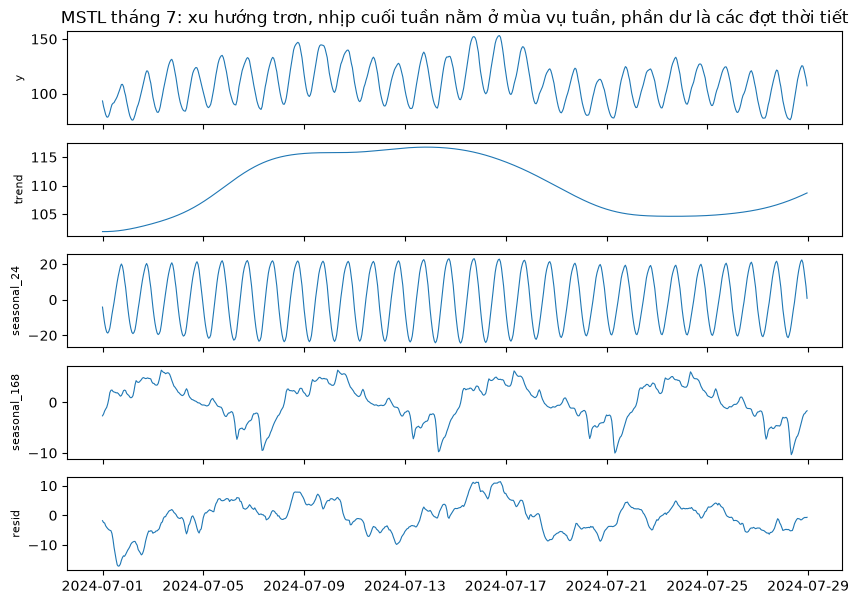

biên độ mùa vụ ngày (GW) theo tháng: {1: 14.4, 2: 13.3, 3: 13.0, 4: 15.8, 5: 25.2, 6: 39.1, 7: 43.3, 8: 39.6, 9: 30.0, 10: 18.6, 11: 15.6, 12: 14.5}
giờ đỉnh tháng 1 và tháng 7: 19 h, 18 h


In [7]:
print("MSTL trên chuỗi còn NaN → số giá trị không NaN của xu hướng:", MSTL(y_goc, periods=(24, 168)).fit().trend.notna().sum())
stl = STL(y, period=24).fit()
print(f"phương sai phần dư: STL(period=24) mặc định {stl.resid.var() / 1e6:.1f} GW² | MSTL {ms['resid'].var() / 1e6:.1f} GW²")

fig, truc = plt.subplots(5, 1, figsize=(10, 7), sharex=True)
for ax, c in zip(truc, ["y", "trend", "seasonal_24", "seasonal_168", "resid"], strict=True):
    s = dia_phuong(ms.loc[thang7, c])
    ax.plot(s.index.tz_localize(None), s.to_numpy() / 1000, lw=0.8)
    ax.set_ylabel(c, fontsize=8)
truc[0].set_title("MSTL tháng 7: xu hướng trơn, nhịp cuối tuần nằm ở mùa vụ tuần, phần dư là các đợt thời tiết")
plt.show()

s24 = dia_phuong(ms["seasonal_24"])
ho = s24.groupby([s24.index.month, s24.index.hour]).mean().unstack() / 1000
bien_do = ho.max(axis=1) - ho.min(axis=1)
print("biên độ mùa vụ ngày (GW) theo tháng:", bien_do.round(1).to_dict())
print("giờ đỉnh tháng 1 và tháng 7:", ho.loc[1].idxmax(), "h,", ho.loc[7].idxmax(), "h")

Hai bẫy: còn một NaN thì MSTL trả **toàn NaN** mà không báo gì; và STL mặc định cho phần dư chỉ 2,8 GW², nhỏ hơn MSTL (16,5) — nhỏ
không phải vì tốt, mà vì xu hướng 47 giờ đủ mềm để nuốt cả nhịp tuần lẫn thời tiết. Mùa vụ ngày của MSTL có biên độ tháng 7
(43,3 GW) gấp 3 tháng 1 (14,4 GW), và đổi hình: mùa đông đỉnh tối, mùa hè đỉnh chiều.

**Bài học.** STL cho mùa vụ đổi dần, MSTL tách nhiều chu kỳ. Phần dư nhỏ chưa chắc là phân rã tốt — xem xu hướng có nuốt mất gì không.

## 5. Độ mạnh mùa vụ là con số của một phân rã, không của riêng dữ liệu

**Vấn đề.** "Chuỗi này mùa vụ mạnh không?" cần một con số để so giữa các chuỗi và các phân rã.

> **độ mạnh xu hướng / mùa vụ** · *strength of trend / seasonality*
>
> - **Là gì:** số từ 0 tới 1: $F_S = 1 - \operatorname{Var}(R) / \operatorname{Var}(S + R)$ — phần dư nhỏ tới đâu so với mùa vụ cộng phần dư (tương tự $F_T$ với xu hướng).
> - **Ví dụ:** Var(phần dư) 0,786, Var(mùa vụ + phần dư) 32,21 → $F_S$ = 1 − 0,024 = 0,976: mùa vụ rất mạnh.
> - **Để làm gì:** so "mùa vụ mạnh cỡ nào" giữa các chuỗi — mạnh thì seasonal naive đã tốt.
>
> 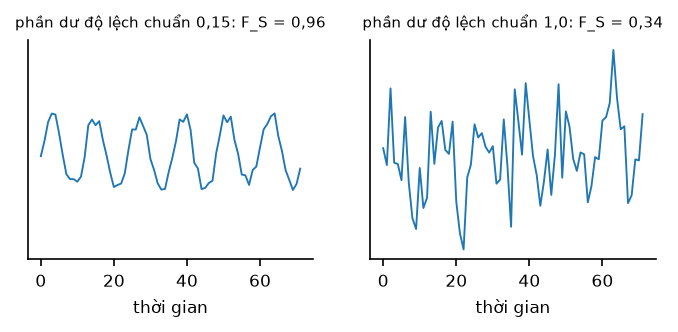

**Lý do.** Phần dư rất nhỏ so với mùa vụ thì mùa vụ "mạnh". Công thức (FPP §4.3), kết quả âm thì ghi 0:

$$F_T = \max\left(0,\ 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(T_t + R_t)}\right), \qquad
F_S = \max\left(0,\ 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}\right)$$

Có nhiều mùa vụ thì tính $F_S$ cho từng thành phần, cùng một phần dư.

**Kết quả.**

In [8]:
def do_manh(bang):
    r = bang["resid"]
    kq = {"F_T": max(0.0, float(1 - r.var() / (bang["trend"] + r).var()))}
    for c in [c for c in bang.columns if c.startswith("seasonal")]:
        kq["F_S_" + c.split("_")[1]] = max(0.0, float(1 - r.var() / (bang[c] + r).var()))
    return kq


ok = ~np.isnan(T)                                           # 8 quý có xu hướng
tay = pd.DataFrame({"trend": T[ok], "seasonal_4": S[ok], "resid": R[ok]})
print("ví dụ 8 quý:", {k: round(v, 3) for k, v in do_manh(tay).items()})
print("cổ điển 24 :", {k: round(v, 3) for k, v in do_manh(cd).items()})
print("MSTL       :", {k: round(v, 3) for k, v in do_manh(ms).items()})

ví dụ 8 quý: {'F_T': 0.838, 'F_S_4': 0.976}
cổ điển 24 : {'F_T': 0.828, 'F_S_24': 0.618}
MSTL       : {'F_T': 0.888, 'F_S_24': 0.829, 'F_S_168': 0.415}


Cùng một chuỗi PJM, $F_{S,24}$ nhảy từ 0,618 (cổ điển) lên 0,829 (MSTL) chỉ vì đổi cách phân rã: cổ điển để mùa vụ đổi theo mùa
trong phần dư, phần dư to, $F_S$ thấp. Mùa vụ tuần của MSTL yếu hơn hẳn mùa vụ ngày (0,415).

**Bài học.** Báo $F$ phải kèm tên phương pháp phân rã.

## 6. Robust cứu được một giờ hỏng, không tách được đợt nắng nóng

**Vấn đề.** Giờ 17:00 UTC ngày 21/11 báo 56.260 MW giữa hai giờ khoảng 95.000 MW. Không robust thì phân rã cố "giải thích" cú rơi đó
bằng xu hướng và mùa vụ, làm méo cả những ngày không có lỗi.

> **robust** · *robust fitting*
>
> - **Là gì:** cách ước lượng ít bị vài điểm bất thường kéo lệch. Trong STL: lượt sau giảm trọng số điểm có phần dư lớn, $\rho = (1 - u^2)^2$ với $u$ = |phần dư| / (6 × trung vị |phần dư|), $u \ge 1$ thì trọng số 0.
> - **Ví dụ:** phần dư 1, −2, 1, 20, −1: $h$ = 6 × 1 = 6; điểm 20 có $u$ ≈ 3,3 → trọng số 0; điểm −2 → 0,79.
> - **Để làm gì:** một giờ số liệu hỏng không làm méo mùa vụ cả tuần; lỗi nằm lại trong phần dư để tìm ra.
>
> 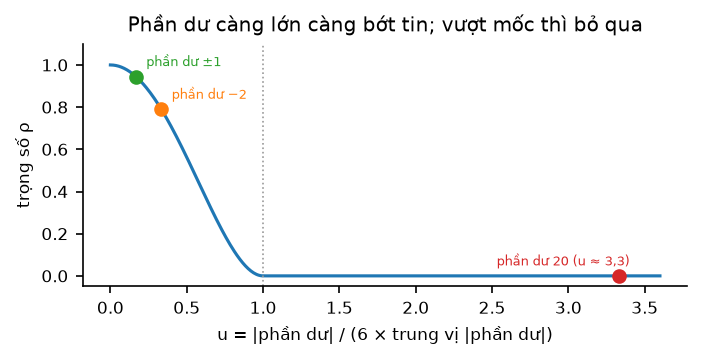

**Lý do.** Robust phân rã hai lượt: lượt đầu tính phần dư; điểm nào phần dư quá lớn thì lượt sau bớt tin nó khi ước lượng xu hướng và
mùa vụ. Điểm đó không bị xoá — nó nằm trọn trong phần dư.

**Kết quả.** (MSTL robust chạy khoảng 10 giây.)

trọng số ví dụ: [0.95 0.79 0.95 0.   0.95]
không robust  mùa vụ ngày 20/11 17:00 UTC -4,051 MW | phần dư giờ hỏng -26,322 MW
robust        mùa vụ ngày 20/11 17:00 UTC +2,117 MW | phần dư giờ hỏng -36,323 MW


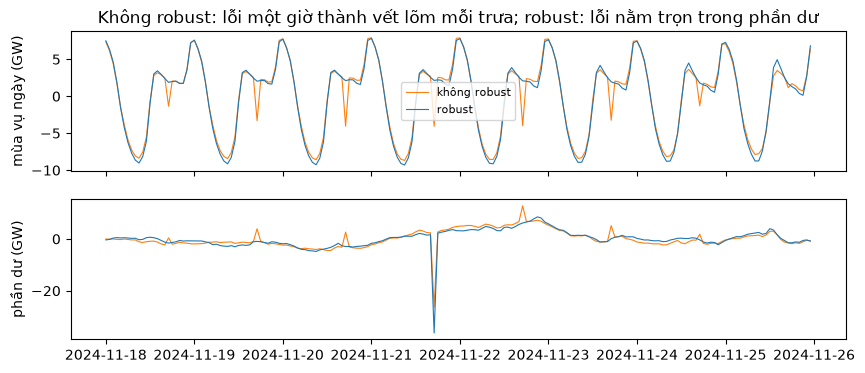

đợt nóng 15–17/7, phần dư lớn nhất: không robust 11,364 MW | robust 22,576 MW
độ mạnh khi robust: {'F_T': 0.817, 'F_S_24': 0.739, 'F_S_168': 0.252}


In [9]:
phan_du = np.array([1, -2, 1, 20, -1])
u = np.abs(phan_du) / (6 * np.median(np.abs(phan_du)))
print("trọng số ví dụ:", np.where(u < 1, (1 - u**2) ** 2, 0).round(2))

rb_kq = MSTL(y, periods=(24, 168), stl_kwargs={"robust": True}).fit()
rb = pd.DataFrame({"y": y, "trend": rb_kq.trend, "resid": rb_kq.resid}).join(rb_kq.seasonal)
t0 = pd.Timestamp("2024-11-21 17:00")
for ten, bang in [("không robust", ms), ("robust", rb)]:
    print(f"{ten:<13} mùa vụ ngày 20/11 17:00 UTC {bang.loc[t0 - pd.Timedelta('1D'), 'seasonal_24']:+,.0f} MW | "
          f"phần dư giờ hỏng {bang.loc[t0, 'resid']:+,.0f} MW")

tuan11 = slice("2024-11-18", "2024-11-25")
fig, truc = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ten, bang, mau in [("không robust", ms, "tab:orange"), ("robust", rb, "tab:blue")]:
    truc[0].plot(bang.loc[tuan11, "seasonal_24"] / 1000, color=mau, lw=0.8, label=ten)
    truc[1].plot(bang.loc[tuan11, "resid"] / 1000, color=mau, lw=0.8)
truc[0].set(ylabel="mùa vụ ngày (GW)", title="Không robust: lỗi một giờ thành vết lõm mỗi trưa; robust: lỗi nằm trọn trong phần dư")
truc[1].set_ylabel("phần dư (GW)")
truc[0].legend(fontsize=8)
plt.show()

nong = slice("2024-07-15", "2024-07-17")
print(f"đợt nóng 15–17/7, phần dư lớn nhất: không robust {ms.loc[nong, 'resid'].max():,.0f} MW | robust {rb.loc[nong, 'resid'].max():,.0f} MW")
print("độ mạnh khi robust:", {k: round(v, 3) for k, v in do_manh(rb).items()})

Không robust làm mùa vụ của ngày 20/11 — ngày **không có lỗi** — lệch khoảng 6.200 MW; robust giữ gần trọn cú rơi trong phần dư,
đúng chỗ để tìm ngoại lai ở buổi 11. Đợt nắng nóng thì khác: một khối nhiều ngày, phân rã không biết "bình thường" của những ngày đó,
nên phần lớn đợt nóng chạy vào xu hướng và mùa vụ; phần dư lớn nhất chỉ 11.364 MW (không robust) và 22.576 MW (robust). Độ mạnh robust thấp hơn vì phần dư robust
giữ trọn các điểm lạ, không phải vì phân rã kém.

**Bài học.** Robust cho điểm nhọn, không cho sự kiện kéo dài — muốn tách đợt nóng phải thêm biến nhiệt độ (buổi 8).

> **X-13ARIMA-SEATS**
>
> - **Là gì:** chương trình khử mùa vụ của cơ quan thống kê Mỹ, cho dữ liệu tháng và quý, xử lý cả ngày lễ và số ngày làm việc.
> - **Ví dụ:** doanh số bán lẻ "đã điều chỉnh mùa vụ" mà Census công bố được làm theo cách này.
> - **Để làm gì:** hiểu các chuỗi "đã khử mùa vụ" chính thức đến từ đâu; không dùng cho dữ liệu giờ.

Chuỗi **đã khử mùa vụ** ($y - S$) vẫn chứa phần dư nên không trơn; muốn tìm điểm đổi chiều thì đọc **xu hướng**, đừng đọc chuỗi
khử mùa vụ.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Vùng khác.** MSTL (24, 168) cho Texas và New England:

In [10]:
for vung in ["PJM", "ERCO", "ISNE"]:
    yv = nhu_cau(vung).interpolate(method="time")
    kq = MSTL(yv, periods=(24, 168)).fit()
    bang = pd.DataFrame({"y": yv, "trend": kq.trend, "resid": kq.resid}).join(kq.seasonal)
    tl = ho_so_phan_du(bang, ("dayofweek", "hour")).var() / yv.var()
    print(f"{vung:<5} {len(yv):,} giờ | " + " | ".join(f"{k} {v:.3f}" for k, v in do_manh(bang).items()) + f" | tỷ lệ thứ×giờ {tl:.5f}")

PJM   8,784 giờ | F_T 0.888 | F_S_24 0.829 | F_S_168 0.415 | tỷ lệ thứ×giờ 0.00001
ERCO  8,784 giờ | F_T 0.920 | F_S_24 0.885 | F_S_168 0.277 | tỷ lệ thứ×giờ 0.00001
ISNE  8,784 giờ | F_T 0.842 | F_S_24 0.753 | F_S_168 0.350 | tỷ lệ thứ×giờ 0.00002


Texas có nhịp tuần yếu nhất ($F_{S,168}$ 0,277), New England ở giữa (0,350), PJM mạnh nhất (0,415). Texas lại có nhịp ngày
mạnh nhất (0,885): phần lớn dao động quanh xu hướng ở đó lặp theo giờ trong ngày, bất kể thứ mấy. Heatmap phần dư thứ × giờ của cả
ba vùng gần như trắng (tỷ lệ mẫu hình cỡ 0,00001) — MSTL đã tách hết nhịp tuần, chỉ là nhịp đó mạnh yếu khác nhau.

**Bài 2 — Cửa sổ mùa vụ** (mặc định của statsmodels cho hai chu kỳ này là 11 và 15):

In [11]:
for cua_so in [(7, 7), (11, 15), (51, 51)]:
    kq = MSTL(y, periods=(24, 168), windows=cua_so).fit()
    s = dia_phuong(kq.seasonal["seasonal_24"])
    h = s.groupby([s.index.month, s.index.hour]).mean().unstack()
    print(f"windows={cua_so}: biên độ mùa vụ ngày tháng 7 {(h.loc[7].max() - h.loc[7].min()) / 1000:.1f} GW | "
          f"phương sai phần dư {kq.resid.var() / 1e6:.1f} GW²")

windows=(7, 7): biên độ mùa vụ ngày tháng 7 43.3 GW | phương sai phần dư 13.7 GW²
windows=(11, 15): biên độ mùa vụ ngày tháng 7 43.3 GW | phương sai phần dư 16.5 GW²
windows=(51, 51): biên độ mùa vụ ngày tháng 7 43.0 GW | phương sai phần dư 20.2 GW²


Trung bình theo tháng, biên độ mùa vụ ngày tháng 7 gần như không đổi (43,3 → 43,0 GW): cả ba cửa sổ đều theo kịp nhịp đổi theo
mùa. Khác nhau ở phần dư: cửa sổ nhỏ (7) cho mùa vụ đổi nhanh tới mức bám theo từng đợt thời tiết, nên phần dư nhỏ nhất (13,7 GW²)
nhưng mùa vụ lẫn cả thời tiết; cửa sổ lớn (51) cho mùa vụ gần cố định, phần dư to nhất (20,2 GW²). Chọn theo việc mùa vụ nên đổi
nhanh cỡ nào, không theo phần dư nhỏ nhất.

**Bài 3 — Ba mùa vụ** với chu kỳ năm 8.766 giờ trên chuỗi một năm:

In [12]:
with warnings.catch_warnings(record=True) as canh_bao:
    warnings.simplefilter("always")
    kq3 = MSTL(y, periods=(24, 168, 8766)).fit()
print("các thành phần mùa vụ:", list(kq3.seasonal.columns))
print("cảnh báo:", [str(c.message)[:90] for c in canh_bao])

các thành phần mùa vụ: ['seasonal_24', 'seasonal_168']
cảnh báo: ['A period(s) is larger than half the length of time series. Removing these period(s).']


Chu kỳ năm dài hơn nửa chuỗi (8.784 giờ) nên bị **bỏ âm thầm** — chỉ một cảnh báo, không lỗi. Muốn tách mùa vụ năm cần ít nhất hai
năm dữ liệu; với một năm, mùa trong năm nằm trong xu hướng.

## Tự kiểm

- [ ] Tính tay xu hướng 2×4-MA tại một điểm, giải thích vì sao hai đầu nửa trọng số.
- [ ] Nói được hai chỗ mùa vụ trốn khi phân rã cổ điển chu kỳ 24.
- [ ] Giải thích vì sao phần dư của STL mặc định nhỏ mà không tốt.
- [ ] Tính $F_S$ từ hai phương sai, và giải thích vì sao phải ghi kèm tên phân rã.
- [ ] Tính trọng số robust cho phần dư 2, −2, 2, −2, 30.